# Lab 6: Training, Tuning, and Scaling k-Nearest Neighbors

In Lab 5, you built 1-nearest-neighbor and k-nearest-neighbors classifiers from scratch. In this lab, you will use **scikit-learn** to carry out the same algorithm, then study three questions that arise when we build a real classifier:

1. How does performance change when the model gets more training data?
2. How should we choose the hyperparameter $k$ without using the test set?
3. What happens when the features used to measure distance have very different scales?

You will answer the first two questions with the Spotify data from Lab 5, repeat the analysis with steel-plate faults, and then fix the steel classifier using a `StandardScaler` inside a scikit-learn pipeline.

You should complete this entire lab so that all tests pass.


In [1]:
in_colab = "google.colab" in str(get_ipython())
if in_colab:
    !pip install otter-grader==6.1.6

from pathlib import Path
import shutil
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

path = 'labs/lab06/build/student'
if in_colab and not Path('data').exists():
    !wget -q -O /content/course.zip https://github.com/dsc-courses/cosmos-ml-cluster-2026/archive/refs/heads/main.zip
    with zipfile.ZipFile('/content/course.zip') as course_zip:
        archive_prefix = f'cosmos-ml-cluster-2026-main/{path}/'
        members = [name for name in course_zip.namelist() if name.startswith(archive_prefix)]
        course_zip.extractall('/content/course-assets', members)
    source_path = Path('/content/course-assets') / archive_prefix
    shutil.copytree(source_path / 'data', 'data', dirs_exist_ok=True)
    shutil.copytree(source_path / 'tests', 'tests', dirs_exist_ok=True)

import otter
grader = otter.Notebook()

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['figure.figsize'] = (10, 5)


## 1. k-NN with scikit-learn 🎵

We will begin with the same Spotify data and seven numerical features used in Lab 5. Recall that the target is the song's genre: classical, hip-hop, or rock.


In [2]:
spotify = pd.read_csv('data/spotify-three-genres.csv').rename(columns={'track_genre': 'genre'})
spotify_features = [
    'danceability', 'energy', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence'
]

X_spotify = spotify[spotify_features]
y_spotify = spotify['genre']
spotify.head()


,track_id,artists,track_name,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,genre
0,0fMditvyHKtvP0Wda7b3Wt,Wolfgang Amadeus Mozart;Danielle Laval,12 Variations on ‘La belle Françoise’ in E fla...,0.389,0.11300,0.0382,0.991,0.84200,0.1360,0.740,classical
1,0JAzwrikHrPWVK02ANRkHl,Wolfgang Amadeus Mozart;Giuseppe Greco,"Piano Sonata No. 17 in B-Flat Major, K. 570: I...",0.445,0.00884,0.0780,0.995,0.91300,0.0907,0.216,classical
2,7FM43USRDOLBicvp6Zvnjk,Wolfgang Amadeus Mozart;I Musici;Pina Carmirelli,"Serenade in G, K.525: 1. Allegro",0.449,0.24700,0.0405,0.866,0.86900,0.2160,0.620,classical
3,4N9wT4gXdCIVIoyYrGQ5ms,Wolfgang Amadeus Mozart;Wiener Mozart Ensemble...,"Contredanse in E flat, K.607 ""Il Trionfo delle...",0.636,0.20300,0.0412,0.964,0.32600,0.1710,0.717,classical
4,58ina5MM56CHWVlIbXiAZT,Antonio Vivaldi;Gidon Kremer;Leslie Pearson;Lo...,"Violin Concerto in F Minor, Op. 8, No. 4, RV 2...",0.513,0.28700,0.0472,0.976,0.00247,0.0991,0.265,classical


### Recreating 5-NN

A scikit-learn model follows a common pattern:

1. Create the model, choosing its hyperparameters.
2. Call `.fit(X_train, y_train)` to train it.
3. Call `.predict(X_new)` or `.score(X_new, y_new)` to use it.

For a classifier, `.score` returns the proportion of correct predictions—its accuracy.

The next cell recreates Lab 5's fixed train/test split so that we can compare implementations.


In [3]:
lab05_test_indices = spotify.sample(frac=0.2, random_state=42).index
X_lab05_train = X_spotify.drop(index=lab05_test_indices)
X_lab05_test = X_spotify.loc[lab05_test_indices]
y_lab05_train = y_spotify.drop(index=lab05_test_indices)
y_lab05_test = y_spotify.loc[lab05_test_indices]


**Question 1.1.** Create a `KNeighborsClassifier` named `spotify_5nn` with 5 neighbors. Fit it using `X_lab05_train` and `y_lab05_train`. Then store its predictions for `X_lab05_test` in `sklearn_predictions` and its accuracy on that test set in `sklearn_accuracy`.

Your accuracy should match the accuracy of the 5-NN classifier you built from scratch in Lab 5.


In [4]:
# BEGIN SOLUTION
spotify_5nn = KNeighborsClassifier(n_neighbors=5)
spotify_5nn.fit(X_lab05_train, y_lab05_train)
sklearn_predictions = spotify_5nn.predict(X_lab05_test)
sklearn_accuracy = spotify_5nn.score(X_lab05_test, y_lab05_test)
# END SOLUTION

sklearn_accuracy


0.8678571428571429

In [5]:
bool(isinstance(spotify_5nn, KNeighborsClassifier) and spotify_5nn.n_neighbors == 5)


True

In [6]:
bool(len(sklearn_predictions) == len(X_lab05_test))


True

In [7]:
bool(np.isclose(sklearn_accuracy, 0.8678571428571429))


True

### Training, validation, and test sets

Lab 5 compared several values of $k$ using the test set. That was useful while learning the algorithm, but it creates a problem: if we use test performance to choose $k$, then the test set has influenced our model.

We will instead divide the data into three sets:

| Set | Purpose |
| --- | --- |
| **Training** | Fit the model. |
| **Validation** | Compare choices such as different values of $k$. |
| **Test** | Evaluate the final procedure once, after all choices have been made. |

We want a 60% training, 20% validation, and 20% test split. We can get this with two calls to `train_test_split`:

1. Split the full data into 80% development data and 20% test data.
2. Split the development data into 75% training and 25% validation data. Since 25% of 80% is 20%, the final proportions are 60/20/20.

Setting `stratify=y` keeps the proportions of the three genres similar in every split.


**Question 1.2.** Split `X_spotify` and `y_spotify` into training, validation, and test sets using the procedure above.

- Use `random_state=0` and `stratify=y_spotify` in the first split.
- Use `random_state=0` and stratify using the development labels in the second split.
- Use `test_size=0.2` for the first split and `test_size=0.25` for the second.

Name the first split `X_spotify_dev`, `X_spotify_test`, `y_spotify_dev`, and `y_spotify_test`. Name the second split `X_spotify_train`, `X_spotify_valid`, `y_spotify_train`, and `y_spotify_valid`.


In [8]:
# BEGIN SOLUTION
X_spotify_dev, X_spotify_test, y_spotify_dev, y_spotify_test = train_test_split(
    X_spotify,
    y_spotify,
    test_size=0.2,
    random_state=0,
    stratify=y_spotify,
)

X_spotify_train, X_spotify_valid, y_spotify_train, y_spotify_valid = train_test_split(
    X_spotify_dev,
    y_spotify_dev,
    test_size=0.25,
    random_state=0,
    stratify=y_spotify_dev,
)
# END SOLUTION

print(f'Training rows:   {len(X_spotify_train):,}')
print(f'Validation rows: {len(X_spotify_valid):,}')
print(f'Test rows:       {len(X_spotify_test):,}')


Training rows:   1,679
Validation rows: 560
Test rows:       560


In [9]:
bool((len(X_spotify_train), len(X_spotify_valid), len(X_spotify_test)) == (1679, 560, 560))


True

In [10]:
bool(set(X_spotify_train.index).isdisjoint(X_spotify_valid.index) and set(X_spotify_train.index).isdisjoint(X_spotify_test.index) and set(X_spotify_valid.index).isdisjoint(X_spotify_test.index))


True

In [11]:
bool(X_spotify_train.index.equals(y_spotify_train.index) and X_spotify_valid.index.equals(y_spotify_valid.index) and X_spotify_test.index.equals(y_spotify_test.index))


True

In [12]:
bool(y_spotify_train.value_counts().max() - y_spotify_train.value_counts().min() <= 1)


True

### Measuring error

**Classification error** is the proportion of incorrect predictions. Since accuracy is the proportion correct,

$$\text{error} = 1 - \text{accuracy}.$$

**Training error** measures the examples used to fit a model. **Validation error** measures separate examples that were not used during fitting.


**Question 1.3.** Complete the function `train_valid_errors`. It takes an already-fitted model and returns a Series containing its training and validation errors. The Series must have the index labels `'train_error'` and `'valid_error'`, in that order.


In [13]:
def train_valid_errors(model, X_train, y_train, X_valid, y_valid):
    """Return the training and validation classification errors of a fitted model."""
    # BEGIN SOLUTION
    return pd.Series({
        'train_error': 1 - model.score(X_train, y_train),
        'valid_error': 1 - model.score(X_valid, y_valid),
    })
    # END SOLUTION

spotify_5nn_split = KNeighborsClassifier(n_neighbors=5).fit(X_spotify_train, y_spotify_train)
train_valid_errors(
    spotify_5nn_split,
    X_spotify_train,
    y_spotify_train,
    X_spotify_valid,
    y_spotify_valid,
)


train_error    0.105420
valid_error    0.133929
dtype: float64

In [14]:
bool(train_valid_errors(spotify_5nn_split, X_spotify_train, y_spotify_train, X_spotify_valid, y_spotify_valid).index.tolist() == ['train_error', 'valid_error'])


True

In [15]:
bool(np.allclose(train_valid_errors(spotify_5nn_split, X_spotify_train, y_spotify_train, X_spotify_valid, y_spotify_valid).to_numpy(), [0.10541989279332931, 0.1339285714285714]))


True

### What happens when we get more training data?

We will train 5-NN using increasingly large subsets of the training set. Every model will be evaluated on the same validation set. The test set remains untouched.

The fixed random ordering below makes the subsets nested: the 100-row subset contains the first 50 rows, the 200-row subset contains the first 100, and so on.


In [16]:
spotify_training_sizes = [50, 100, 200, 400, 800, 1200, len(X_spotify_train)]
spotify_training_order = X_spotify_train.sample(frac=1, random_state=0).index


**Question 1.4.** For every size in `spotify_training_sizes`:

1. Select the first `size` rows from `spotify_training_order`.
2. Fit a new 5-NN classifier using only those rows.
3. Compute its training error on that subset and its validation error on the full validation set.

Store the results in a DataFrame named `spotify_errors_by_size`. Its index should be named `'num_training_points'`, and its two columns should be `'train_error'` and `'valid_error'`. Then make a line plot of both errors with markers.


,train_error,valid_error
num_training_points,,
50,0.22000,0.241071
100,0.18000,0.225000
200,0.14500,0.198214
400,0.13000,0.210714
800,0.09625,0.171429
1200,0.10500,0.155357
1679,0.10542,0.133929


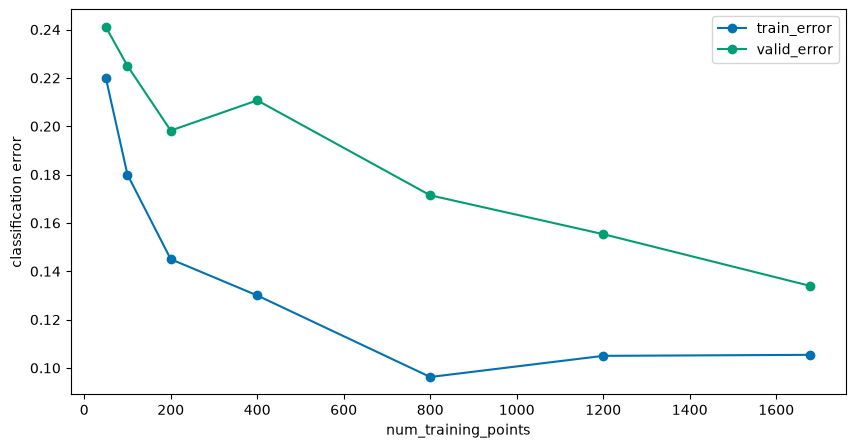

In [17]:
# BEGIN SOLUTION
spotify_size_rows = []

for size in spotify_training_sizes:
    subset_index = spotify_training_order[:size]
    X_subset = X_spotify_train.loc[subset_index]
    y_subset = y_spotify_train.loc[subset_index]

    model = KNeighborsClassifier(n_neighbors=5).fit(X_subset, y_subset)
    errors = train_valid_errors(model, X_subset, y_subset, X_spotify_valid, y_spotify_valid)
    spotify_size_rows.append({
        'num_training_points': size,
        'train_error': errors['train_error'],
        'valid_error': errors['valid_error'],
    })

spotify_errors_by_size = pd.DataFrame(spotify_size_rows).set_index('num_training_points')
spotify_errors_by_size.plot(marker='o', ylabel='classification error');
# END SOLUTION

spotify_errors_by_size


In [18]:
bool(isinstance(spotify_errors_by_size, pd.DataFrame) and spotify_errors_by_size.index.tolist() == spotify_training_sizes)


True

In [19]:
bool(spotify_errors_by_size.columns.tolist() == ['train_error', 'valid_error'])


True

In [20]:
bool(np.allclose(spotify_errors_by_size.iloc[[0, -1]].to_numpy(), [[0.22, 0.2410714285714286], [0.10541989279332931, 0.1339285714285714]]))


True

**Pause and interpret the graph.** As the number of training songs grows, what generally happens to validation error? Why is the curve not perfectly smooth? Why have we still not used `X_spotify_test`?


### What happens as $k$ increases?

The number of neighbors is a **hyperparameter**: we choose it before fitting the model. Small values of $k$ create a flexible rule that can be strongly affected by individual training examples. Very large values make many distant songs vote, producing a rule that may be too simple.

The values below cover both extremes. They are unevenly spaced, so we will use a logarithmic horizontal axis when plotting them.


In [21]:
k_values = [1, 5, 15, 25, 101, 401, 801]


**Question 1.5.** Fit one Spotify k-NN classifier for every value in `k_values`, always using the entire Spotify training set. Store the training and validation errors in `spotify_errors_by_k`, indexed by `k`, with columns `'train_error'` and `'valid_error'`.

Make a line plot of both errors with markers. Set the horizontal axis to logarithmic scale using `plt.xscale('log')`.


,train_error,valid_error
k,,
1,0.000000,0.150000
5,0.105420,0.133929
15,0.132222,0.144643
25,0.145920,0.158929
101,0.150089,0.166071
401,0.177487,0.200000
801,0.237046,0.276786


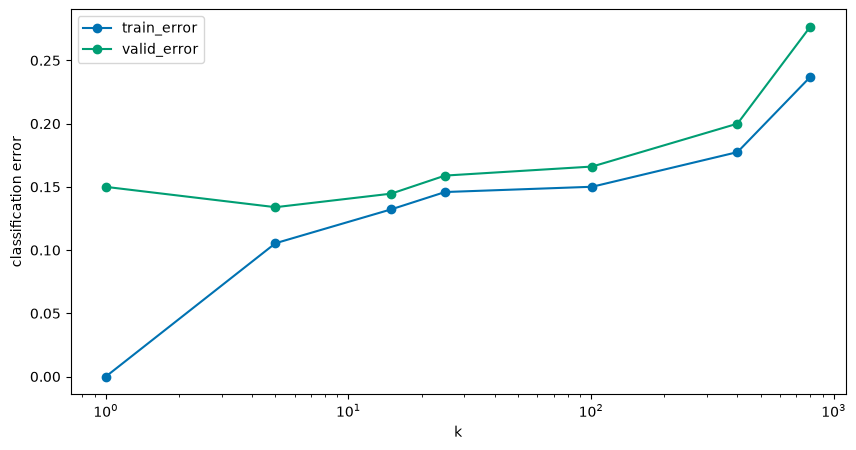

In [22]:
# BEGIN SOLUTION
spotify_k_rows = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k).fit(X_spotify_train, y_spotify_train)
    errors = train_valid_errors(
        model,
        X_spotify_train,
        y_spotify_train,
        X_spotify_valid,
        y_spotify_valid,
    )
    spotify_k_rows.append({
        'k': k,
        'train_error': errors['train_error'],
        'valid_error': errors['valid_error'],
    })

spotify_errors_by_k = pd.DataFrame(spotify_k_rows).set_index('k')
spotify_errors_by_k.plot(marker='o', ylabel='classification error');
plt.xscale('log')
# END SOLUTION

spotify_errors_by_k


In [23]:
bool(isinstance(spotify_errors_by_k, pd.DataFrame) and spotify_errors_by_k.index.tolist() == k_values)


True

In [24]:
bool(spotify_errors_by_k.columns.tolist() == ['train_error', 'valid_error'])


True

In [25]:
bool(np.allclose(spotify_errors_by_k['valid_error'].to_numpy(), [0.15, 0.1339285714285714, 0.14464285714285718, 0.15892857142857142, 0.16607142857142854, 0.19999999999999996, 0.2767857142857143]))


True

In [26]:
bool(spotify_errors_by_k.loc[1, 'train_error'] == 0)


True

The validation error first decreases and then increases. We choose the value of $k$ at the bottom of this **validation-error valley**. The training error, however, generally increases with $k$. A model can fit its training data extremely well and still be worse on unseen data.


**Question 1.6.** Set `best_spotify_k` to the value of $k$ with the smallest validation error. If there is a tie, `.idxmin()` will choose the first tied value.

Now that $k$ has been chosen, combine the training and validation sets, fit a new classifier named `final_spotify_model` using all of that development data, and store its error on the untouched test set in `spotify_test_error`.


In [27]:
# BEGIN SOLUTION
best_spotify_k = spotify_errors_by_k['valid_error'].idxmin()

X_spotify_train_valid = pd.concat([X_spotify_train, X_spotify_valid])
y_spotify_train_valid = pd.concat([y_spotify_train, y_spotify_valid])

final_spotify_model = KNeighborsClassifier(n_neighbors=best_spotify_k)
final_spotify_model.fit(X_spotify_train_valid, y_spotify_train_valid)
spotify_test_error = 1 - final_spotify_model.score(X_spotify_test, y_spotify_test)
# END SOLUTION

best_spotify_k, spotify_test_error


(np.int64(5), 0.16249999999999998)

In [28]:
bool(best_spotify_k == 5)


True

In [29]:
bool(isinstance(final_spotify_model, KNeighborsClassifier) and final_spotify_model.n_neighbors == best_spotify_k)


True

In [30]:
bool(np.isclose(spotify_test_error, 0.1625))


True

## 2. Repeating the process with steel-plate faults 🏭

Each row in the next dataset describes a fault found on the surface of a steel plate. The 24 numerical features are measurements extracted from an image of the fault. The target, `fault_type`, identifies one of seven kinds of faults.

(And remember, the `id` column identifies a row but is not a physical measurement, so it must not be used as a model feature.)


In [31]:
steel = pd.read_csv('data/steel-plate-faults.csv')
steel.head()


,id,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,...,Empty_Index,Square_Index,Outside_X_Index,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,fault_type
0,927,64,92,902589,902622,659,50,34,61890,49,...,0.2868,0.8485,0.0166,0.5600,0.9706,1.0,0.1515,-0.2663,0.9844,Bumps
1,1877,19,57,103914,103916,54,38,2,7498,101,...,0.2895,0.0526,0.0279,1.0000,1.0000,0.0,-0.9474,0.0848,0.1812,Other_Faults
2,827,1302,1308,2369532,2369561,115,18,29,14260,115,...,0.3391,0.2069,0.0044,0.3333,1.0000,1.0,0.7931,-0.0313,0.2984,Dirtiness
3,397,0,828,468317,468520,20726,1193,709,2499819,25,...,0.8767,0.2452,0.5906,0.6941,0.2863,0.0,-0.7548,-0.0577,1.0000,K_Scatch
4,373,919,930,561832,561842,88,11,10,14538,134,...,0.2000,0.9091,0.0079,1.0000,1.0000,0.0,-0.0909,0.2907,0.2173,K_Scatch


**Question 2.1.** Create `X_steel` using every column except `'id'` and `'fault_type'`, and create `y_steel` using the `'fault_type'` column.

Then create 60/20/20 training, validation, and test sets using the same two-step procedure as Question 1.2. Use `random_state=0` and stratify both splits. Follow the same naming pattern as the Spotify variables, replacing `spotify` with `steel` (for example, `X_steel_dev` and `X_steel_train`).


In [32]:
# BEGIN SOLUTION
steel_features = [column for column in steel.columns if column not in ['id', 'fault_type']]
X_steel = steel[steel_features]
y_steel = steel['fault_type']

X_steel_dev, X_steel_test, y_steel_dev, y_steel_test = train_test_split(
    X_steel,
    y_steel,
    test_size=0.2,
    random_state=0,
    stratify=y_steel,
)

X_steel_train, X_steel_valid, y_steel_train, y_steel_valid = train_test_split(
    X_steel_dev,
    y_steel_dev,
    test_size=0.25,
    random_state=0,
    stratify=y_steel_dev,
)
# END SOLUTION

print(f'Training rows:   {len(X_steel_train):,}')
print(f'Validation rows: {len(X_steel_valid):,}')
print(f'Test rows:       {len(X_steel_test):,}')


Training rows:   873
Validation rows: 291
Test rows:       291


In [33]:
bool(steel_features == [column for column in steel.columns if column not in ['id', 'fault_type']])


True

In [34]:
bool((len(X_steel_train), len(X_steel_valid), len(X_steel_test)) == (873, 291, 291))


True

In [35]:
bool(set(X_steel_train.index).isdisjoint(X_steel_valid.index) and set(X_steel_train.index).isdisjoint(X_steel_test.index) and set(X_steel_valid.index).isdisjoint(X_steel_test.index))


True

In [36]:
bool(X_steel_train.index.equals(y_steel_train.index) and X_steel_valid.index.equals(y_steel_valid.index) and X_steel_test.index.equals(y_steel_test.index))


True

In [37]:
steel_training_sizes = [50, 100, 200, 400, 600, 800, len(X_steel_train)]
steel_training_order = X_steel_train.sample(frac=1, random_state=0).index


**Question 2.2.** Repeat Question 1.4 using the steel data. Train a 5-NN classifier with every size in `steel_training_sizes`, and evaluate every classifier using the same steel validation set.

Store the results in `steel_errors_by_size`, indexed by `'num_training_points'`, with columns `'train_error'` and `'valid_error'`. Make a line plot of the errors with markers.


,train_error,valid_error
num_training_points,,
50,0.520000,0.683849
100,0.380000,0.611684
200,0.395000,0.570447
400,0.385000,0.553265
600,0.390000,0.573883
800,0.395000,0.567010
873,0.379152,0.570447


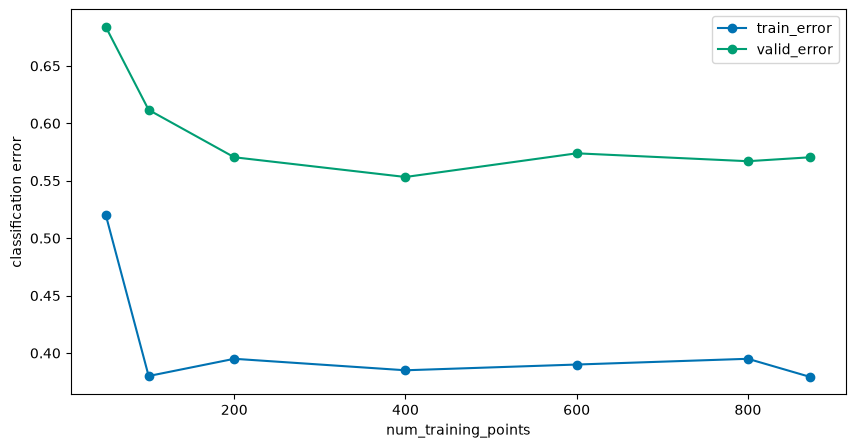

In [38]:
# BEGIN SOLUTION
steel_size_rows = []

for size in steel_training_sizes:
    subset_index = steel_training_order[:size]
    X_subset = X_steel_train.loc[subset_index]
    y_subset = y_steel_train.loc[subset_index]

    model = KNeighborsClassifier(n_neighbors=5).fit(X_subset, y_subset)
    errors = train_valid_errors(model, X_subset, y_subset, X_steel_valid, y_steel_valid)
    steel_size_rows.append({
        'num_training_points': size,
        'train_error': errors['train_error'],
        'valid_error': errors['valid_error'],
    })

steel_errors_by_size = pd.DataFrame(steel_size_rows).set_index('num_training_points')
steel_errors_by_size.plot(marker='o', ylabel='classification error');
# END SOLUTION

steel_errors_by_size


In [39]:
bool(isinstance(steel_errors_by_size, pd.DataFrame) and steel_errors_by_size.index.tolist() == steel_training_sizes)


True

In [40]:
bool(steel_errors_by_size.columns.tolist() == ['train_error', 'valid_error'])


True

In [41]:
bool(np.allclose(steel_errors_by_size.iloc[[0, -1]].to_numpy(), [[0.52, 0.6838487972508591], [0.37915234822451316, 0.570446735395189]]))


True

**Question 2.3.** Repeat Question 1.5 using the entire steel training set and every value in `k_values`.

Store the results in `steel_errors_by_k`, indexed by `k`, with columns `'train_error'` and `'valid_error'`. Make a line plot with markers and a logarithmic horizontal axis.


,train_error,valid_error
k,,
1,0.000000,0.611684
5,0.379152,0.570447
15,0.460481,0.549828
25,0.468499,0.539519
101,0.515464,0.567010
401,0.626575,0.625430
801,0.652921,0.652921


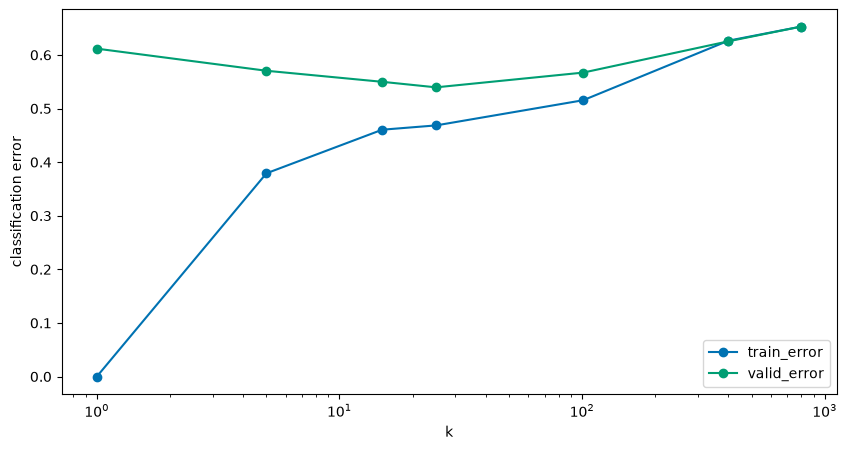

In [42]:
# BEGIN SOLUTION
steel_k_rows = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k).fit(X_steel_train, y_steel_train)
    errors = train_valid_errors(
        model,
        X_steel_train,
        y_steel_train,
        X_steel_valid,
        y_steel_valid,
    )
    steel_k_rows.append({
        'k': k,
        'train_error': errors['train_error'],
        'valid_error': errors['valid_error'],
    })

steel_errors_by_k = pd.DataFrame(steel_k_rows).set_index('k')
steel_errors_by_k.plot(marker='o', ylabel='classification error');
plt.xscale('log')
# END SOLUTION

steel_errors_by_k


In [43]:
bool(isinstance(steel_errors_by_k, pd.DataFrame) and steel_errors_by_k.index.tolist() == k_values)


True

In [44]:
bool(steel_errors_by_k.columns.tolist() == ['train_error', 'valid_error'])


True

In [45]:
bool(np.allclose(steel_errors_by_k['valid_error'].to_numpy(), [0.6116838487972509, 0.570446735395189, 0.5498281786941581, 0.5395189003436427, 0.5670103092783505, 0.6254295532646048, 0.6529209621993127]))


True

**Question 2.4.** Set `best_raw_steel_k` to the value of $k$ with the smallest validation error, and set `best_raw_steel_valid_error` to that error.

Do **not** evaluate this model on the test set. We have not finished making modeling choices yet.


In [46]:
# BEGIN SOLUTION
best_raw_steel_k = steel_errors_by_k['valid_error'].idxmin()
best_raw_steel_valid_error = steel_errors_by_k.loc[best_raw_steel_k, 'valid_error']
# END SOLUTION

best_raw_steel_k, best_raw_steel_valid_error


(np.int64(25), np.float64(0.5395189003436427))

In [47]:
bool(best_raw_steel_k == 25)


True

In [48]:
bool(np.isclose(best_raw_steel_valid_error, 0.5395189003436427))


True

## 3. The feature-scale problem ⚖️

k-NN decides which rows are nearby using distance. This means that the units and scales of the features matter.

Consider two steel features:

- `X_Minimum` is a horizontal pixel coordinate, with values reaching into the thousands.
- `Edges_Index` is a precomputed edge measurement, with values roughly between 0 and 1.

A difference of 100 pixels in `X_Minimum` overwhelms even the largest possible difference in `Edges_Index`. In the distance calculation, `X_Minimum` therefore receives much more influence not because we decided it was more important, but simply because its numbers are larger.


In [49]:
two_features = ['X_Minimum', 'Edges_Index']
X_steel_train[two_features].agg(['min', 'max', 'mean', 'std']).T


,min,max,mean,std
X_Minimum,0.0,1705.0000,562.906071,515.764877
Edges_Index,0.0,0.9952,0.331656,0.294223


### Standardization

`StandardScaler` transforms each feature using statistics learned from the training data:

$$\text{standardized value} = \frac{\text{value} - \text{training mean}}{\text{training standard deviation}}.$$

After this transformation, every training feature has mean 0 and standard deviation 1. A one-unit change then means approximately one training standard deviation, regardless of the feature's original units.


**Question 3.1.** Create a `StandardScaler` named `two_feature_scaler`. Use its `.fit_transform` method to standardize the two columns in `X_steel_train[two_features]`.

Store the result in a DataFrame named `steel_two_standardized`. Give it the same index and column names as `X_steel_train[two_features]`.


In [50]:
# BEGIN SOLUTION
two_feature_scaler = StandardScaler()
steel_two_standardized = pd.DataFrame(
    two_feature_scaler.fit_transform(X_steel_train[two_features]),
    index=X_steel_train.index,
    columns=two_features,
)
# END SOLUTION

steel_two_standardized.head()


,X_Minimum,Edges_Index
383,-0.360654,0.743888
1003,-0.655531,-0.211376
521,-1.016367,-0.938792
545,-1.012487,-0.923148
495,-0.508092,0.100811


In [51]:
bool(isinstance(two_feature_scaler, StandardScaler))


True

In [52]:
bool(isinstance(steel_two_standardized, pd.DataFrame) and steel_two_standardized.index.equals(X_steel_train.index) and steel_two_standardized.columns.tolist() == two_features)


True

In [53]:
bool(np.allclose(steel_two_standardized.mean().to_numpy(), [0, 0], atol=1e-12))


True

In [54]:
bool(np.allclose(steel_two_standardized.to_numpy().std(axis=0), [1, 1]))


True

The plots below use the same physical scale on the horizontal and vertical axes: one unit has the same displayed length in either direction. In the raw plot, the variation in `Edges_Index` is crushed into an almost-flat line. After standardization, both features contribute visible variation. (You don't need to understand the code below, just run it to generate plots.)


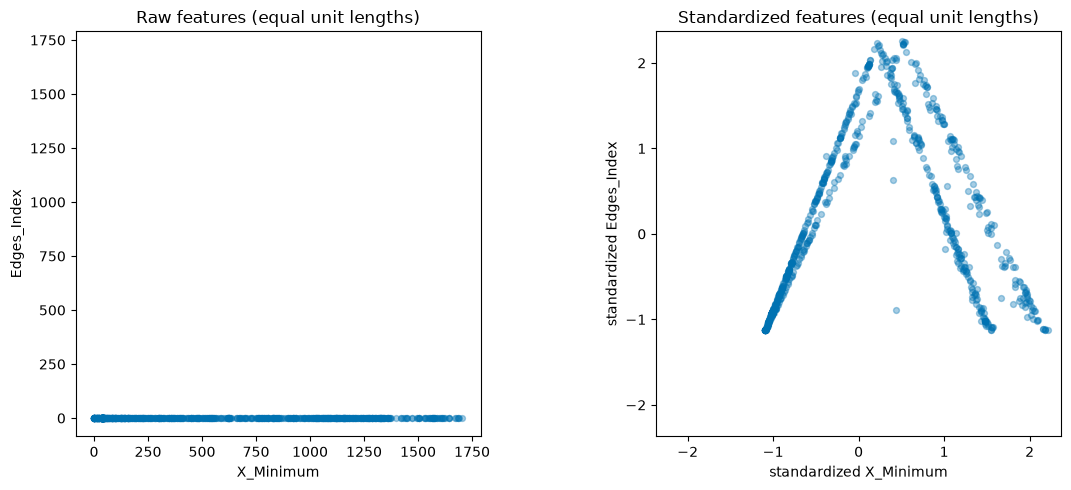

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(
    X_steel_train['X_Minimum'],
    X_steel_train['Edges_Index'],
    alpha=0.35,
    s=18,
)
raw_min = X_steel_train[two_features].min().min()
raw_max = X_steel_train[two_features].max().max()
raw_padding = 0.05 * (raw_max - raw_min)
axes[0].set_xlim(raw_min - raw_padding, raw_max + raw_padding)
axes[0].set_ylim(raw_min - raw_padding, raw_max + raw_padding)
axes[0].set_aspect('equal', adjustable='box')
axes[0].set_title('Raw features (equal unit lengths)')
axes[0].set_xlabel('X_Minimum')
axes[0].set_ylabel('Edges_Index')

axes[1].scatter(
    steel_two_standardized['X_Minimum'],
    steel_two_standardized['Edges_Index'],
    alpha=0.35,
    s=18,
)
standardized_limit = np.abs(steel_two_standardized.to_numpy()).max() * 1.05
axes[1].set_xlim(-standardized_limit, standardized_limit)
axes[1].set_ylim(-standardized_limit, standardized_limit)
axes[1].set_aspect('equal', adjustable='box')
axes[1].set_title('Standardized features (equal unit lengths)')
axes[1].set_xlabel('standardized X_Minimum')
axes[1].set_ylabel('standardized Edges_Index')

plt.tight_layout()


### Putting transformations in a pipeline

We could manually fit a scaler, transform the training data, remember to transform validation and test data using the **same** scaler, and then fit k-NN. A scikit-learn **pipeline** safely combines those steps:

```python
model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=5),
)
```

When `.fit` is called, the pipeline fits the scaler using the training data, transforms the training features, and fits k-NN. When `.predict` or `.score` is called, it transforms new features using the already-fitted scaler before passing them to k-NN.

This prevents us from accidentally fitting a separate scaler to validation or test data.


**Question 3.2.** Create a pipeline named `scaled_steel_5nn` containing a `StandardScaler` followed by a 5-NN classifier. Fit it on the steel training data, then store its training and validation errors in `scaled_steel_5nn_errors` using `train_valid_errors`.


In [56]:
# BEGIN SOLUTION
scaled_steel_5nn = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=5),
)
scaled_steel_5nn.fit(X_steel_train, y_steel_train)
scaled_steel_5nn_errors = train_valid_errors(
    scaled_steel_5nn,
    X_steel_train,
    y_steel_train,
    X_steel_valid,
    y_steel_valid,
)
# END SOLUTION

scaled_steel_5nn_errors


train_error    0.206186
valid_error    0.288660
dtype: float64

In [57]:
bool(list(scaled_steel_5nn.named_steps) == ['standardscaler', 'kneighborsclassifier'])


True

In [58]:
bool(scaled_steel_5nn.named_steps['kneighborsclassifier'].n_neighbors == 5)


True

In [59]:
bool(np.allclose(scaled_steel_5nn_errors.to_numpy(), [0.20618556701030932, 0.28865979381443296]))


True

In [60]:
bool(scaled_steel_5nn_errors['valid_error'] < steel_errors_by_k.loc[5, 'valid_error'])


True

**Question 3.3.** Tune $k$ again, this time creating and fitting a new `StandardScaler`/k-NN pipeline for every value in `k_values`.

Store the errors in `scaled_steel_errors_by_k`, indexed by `k`, with columns `'train_error'` and `'valid_error'`. Set `best_scaled_steel_k` to the value with the smallest validation error.

Finally, create `steel_scaling_comparison`, a DataFrame with columns `'raw features'` and `'standardized features'` containing the two sets of validation errors. Make a line plot of this comparison with markers and a logarithmic horizontal axis.


(np.int64(15),
      train_error  valid_error
 k                            
 1       0.000000     0.329897
 5       0.206186     0.288660
 15      0.263459     0.285223
 25      0.301260     0.316151
 101     0.398625     0.405498
 401     0.481100     0.498282
 801     0.652921     0.652921)

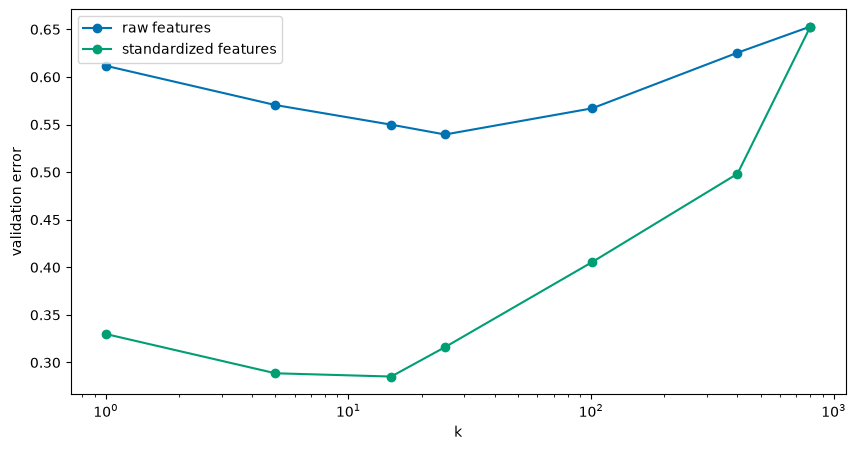

In [61]:
# BEGIN SOLUTION
scaled_steel_k_rows = []

for k in k_values:
    model = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=k),
    )
    model.fit(X_steel_train, y_steel_train)
    errors = train_valid_errors(
        model,
        X_steel_train,
        y_steel_train,
        X_steel_valid,
        y_steel_valid,
    )
    scaled_steel_k_rows.append({
        'k': k,
        'train_error': errors['train_error'],
        'valid_error': errors['valid_error'],
    })

scaled_steel_errors_by_k = pd.DataFrame(scaled_steel_k_rows).set_index('k')
best_scaled_steel_k = scaled_steel_errors_by_k['valid_error'].idxmin()

steel_scaling_comparison = pd.DataFrame({
    'raw features': steel_errors_by_k['valid_error'],
    'standardized features': scaled_steel_errors_by_k['valid_error'],
})
steel_scaling_comparison.plot(marker='o', ylabel='validation error');
plt.xscale('log')
# END SOLUTION

best_scaled_steel_k, scaled_steel_errors_by_k


In [62]:
bool(isinstance(scaled_steel_errors_by_k, pd.DataFrame) and scaled_steel_errors_by_k.index.tolist() == k_values)


True

In [63]:
bool(scaled_steel_errors_by_k.columns.tolist() == ['train_error', 'valid_error'])


True

In [64]:
bool(np.allclose(scaled_steel_errors_by_k['valid_error'].to_numpy(), [0.3298969072164948, 0.28865979381443296, 0.2852233676975945, 0.3161512027491409, 0.4054982817869416, 0.49828178694158076, 0.6529209621993127]))


True

In [65]:
bool(best_scaled_steel_k == 15)


True

In [66]:
bool(steel_scaling_comparison.columns.tolist() == ['raw features', 'standardized features'])


True

Standardization substantially lowers validation error because all 24 features can now influence distance on comparable scales. Notice that we made this comparison using validation data, not test data.


**Question 3.4.** We have finished choosing the preprocessing and the value of $k$. Combine the steel training and validation sets.

Create `final_steel_model`, a new pipeline containing `StandardScaler` and a k-NN classifier using `best_scaled_steel_k`. Fit it using the combined training and validation data. Finally, store its error on the untouched steel test set in `steel_test_error`.

(By the way, feel free to use this model to predict the Kaggle test set! How does it do?)

In [67]:
# BEGIN SOLUTION
X_steel_train_valid = pd.concat([X_steel_train, X_steel_valid])
y_steel_train_valid = pd.concat([y_steel_train, y_steel_valid])

final_steel_model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=best_scaled_steel_k),
)
final_steel_model.fit(X_steel_train_valid, y_steel_train_valid)
steel_test_error = 1 - final_steel_model.score(X_steel_test, y_steel_test)
# END SOLUTION

steel_test_error


0.281786941580756

In [68]:
bool(list(final_steel_model.named_steps) == ['standardscaler', 'kneighborsclassifier'])


True

In [69]:
bool(final_steel_model.named_steps['kneighborsclassifier'].n_neighbors == best_scaled_steel_k)


True

In [70]:
bool(len(final_steel_model.named_steps['standardscaler'].mean_) == len(steel_features))


True

In [71]:
bool(np.isclose(steel_test_error, 0.281786941580756))


True

## Finish Line 🏁

In this lab, you moved from implementing k-NN yourself to using it as part of a complete modeling workflow:

- More training examples generally improve performance on unseen data.
- Training error alone cannot tell us which hyperparameter will generalize best.
- Validation data is used to choose $k$ and preprocessing; test data is reserved for one final evaluation.
- Since k-NN uses distances, features with large numerical scales can dominate its predictions.
- A pipeline fits `StandardScaler` on training data and applies the same transformation before k-NN makes predictions.

Before finishing, discuss these questions with a neighbor:

1. Why did we retrain each final model using both the training and validation sets?
2. Why did standardization help much more for the steel data than for the Spotify data?
3. Why would choosing a new model after seeing its test error make that test error less trustworthy?


In [72]:
# For your convenience, you can run this cell to run all the tests at once!
grader.check_all()


q1_1 results: All test cases passed!

q1_2 results: All test cases passed!

q1_3 results: All test cases passed!

q1_4 results: All test cases passed!

q1_5 results: All test cases passed!

q1_6 results: All test cases passed!

q2_1 results: All test cases passed!

q2_2 results: All test cases passed!

q2_3 results: All test cases passed!

q2_4 results: All test cases passed!

q3_1 results: All test cases passed!

q3_2 results: All test cases passed!

q3_3 results: All test cases passed!

q3_4 results: All test cases passed!